# 11 — Backtesting Strategies

## What you'll learn
- What a **backtest** actually is: replay history, apply a rule mechanically, and measure the result.
- The one rule that makes or breaks a backtest — a signal read from bar *i*'s close can only fill at bar *i+1*'s open (**no lookahead**).
- How to read the headline numbers: total return, CAGR, annualised volatility, Sharpe, max drawdown, win rate, profit factor, and average win/loss.
- Why a strategy can legitimately produce **zero trades**, and why that is a result, not a bug.
- Why a great backtest is not evidence of skill — and what the engine honestly leaves out.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stocklearn.data import get_history, price_series
from stocklearn.orders import market_buy, market_sell
from stocklearn.strategy import (
    Context,
    BuyAndHold,
    SmaCross,
    RsiReversion,
    MacdCross,
    BollingerBreakout,
)
from stocklearn.backtest import run_backtest, summarize_backtest

sns.set_theme(style="whitegrid")

# One place to swap the symbol.
ticker = "AAPL"
period = "2y"

## What a backtest is

A backtest is a **mechanical replay**. You take a fixed slice of history, walk it one bar at a
time, apply a rule exactly as written, and record the resulting orders, fills and equity. No
judgement, no hindsight, no "I would have sold there" — the point is to see what the *rule*
would have done, then decide whether the rule is worth believing.

The rule that makes or breaks it:

> A signal computed from bar $i$'s close can only be filled at bar $i+1$'s open.

Anything else is lookahead. If you let a signal fill at the price you saw when you generated
it, you are quietly peeking at the future — the strategy buys at the exact close that triggered
it, which a real trader could never do.

### Tiny worked example

Six bars, closes `10, 11, 12, 11, 10, 9`:

| Bar | Close | Signal read from this close | Earliest possible fill |
| --- | --- | --- | --- |
| 0 | 10 | — (no prior bar) | — |
| 1 | 11 | close **rose** 10 → 11 ⇒ *buy* | bar 2's **open** |
| 2 | 12 | (already long) | — |
| 3 | 11 | close **fell** 12 → 11 ⇒ *sell* | bar 4's **open** |
| 4 | 10 | — | — |
| 5 | 9 | — | — |

So the "buy 11" signal is filled at bar 2's open, and the "sell 11" signal at bar 4's open.
The signal price (a close) and the fill price (a later open) are **never** the same bar.

In [2]:
# A tiny strategy defined inline, so you can see the whole interface in one place:
# anything with on_bar(ctx) -> list[Order] is a strategy.
class RiseFall:
    name = "Rise/Fall demo"

    def on_bar(self, ctx: Context):
        if len(ctx.close) < 2:
            return []                       # need a previous close to compare
        rose = ctx.close.iloc[-1] > ctx.close.iloc[-2]
        fell = ctx.close.iloc[-1] < ctx.close.iloc[-2]
        if ctx.position_qty == 0 and rose:
            return [market_buy(1)]          # go long one share
        if ctx.position_qty > 0 and fell:
            return [market_sell(ctx.position_qty)]   # flatten
        return []


# Six synthetic bars (business days) with Open == Close for a crisp demonstration.
closes = [10.0, 11.0, 12.0, 11.0, 10.0, 9.0]
synth = pd.DataFrame(
    {
        "Open": closes,
        "High": [c + 0.5 for c in closes],
        "Low": [c - 0.5 for c in closes],
        "Close": closes,
        "Adj Close": closes,
        "Volume": 0,
    },
    index=pd.date_range("2024-01-01", periods=len(closes), freq="B"),
)

demo = run_backtest(RiseFall(), synth, initial_cash=1_000.0)

print("Synthetic bars:")
print(synth[["Open", "Close"]])
print()
print("Orders the strategy emitted (status + the price it actually filled at):")
for o in demo.orders:
    print(f"  id={o.order_id} {o.side.value:4} qty={o.quantity} status={o.status.value:7} fill_price={o.fill_price}")

Synthetic bars:
            Open  Close
2024-01-01  10.0   10.0
2024-01-02  11.0   11.0
2024-01-03  12.0   12.0
2024-01-04  11.0   11.0
2024-01-05  10.0   10.0
2024-01-08   9.0    9.0

Orders the strategy emitted (status + the price it actually filled at):
  id=1 buy  qty=1 status=filled  fill_price=12.0
  id=2 sell qty=1 status=filled  fill_price=10.0


### Read the printed numbers

The buy signal came from bar 1's close of **11**, but `fill_price` is **12** — bar 2's open.
The sell signal came from bar 3's close of **11**, and its fill is bar 4's open of **10**.

Notice the order is the *only* thing the strategy returns; the backtester owns when and at what
price it fills. That separation is what keeps the strategy honest: it can only ever see
`ctx.close`, which ends at the current bar, so it literally cannot quote a future price.

## First real run: buy and hold

`BuyAndHold` is the benchmark every strategy must beat: buy once with everything you have on
the first bar, then never sell. `run_backtest` returns a `BacktestResult` whose `.metrics` dict
holds the headline numbers. We print the metrics and then the ready-made markdown report.

In [3]:
history = get_history(ticker, period=period)

bh = run_backtest(BuyAndHold(), history)

# The metrics dict as a one-column table, so every number is visible at once.
pd.DataFrame(pd.Series(bh.metrics, name="BuyAndHold")).round(4)

,BuyAndHold
initial_cash,10000.0000
final_equity,14630.2666
total_return,0.4630
cagr,0.2114
annualized_volatility,0.2801
sharpe,0.8240
max_drawdown,-0.3253
total_pnl,0.0000
n_trades,0.0000
win_rate,0.0000


In [4]:
print(summarize_backtest(bh))

# Backtest — Buy and hold

| Metric | Value |
| --- | --- |
| Initial cash | $10,000.00 |
| Final equity | $14,630.27 |
| Total return | 46.3% |
| CAGR | 21.1% |
| Annualised volatility | 28.0% |
| Sharpe ratio | 0.82 |
| Max drawdown | -32.5% |
| Realised P&L | $0.00 |
| Trades | 0 |
| Win rate | 0.0% |
| Profit factor | 0.00 |
| Average win | $0.00 |
| Average loss | $0.00 |

## Trades (last 10)

_No closed trades — the strategy never completed a round trip._

> Historical replay: each signal is computed from a bar's close and filled at the next bar's open, with no slippage, latency or partial fills — only the flat commission of $0.00 per fill.

> Educational analysis only — not financial advice. Past performance does not predict future returns.


## What each metric means — and what it would hide on its own

| Metric | What it says | What reading it alone hides |
| --- | --- | --- |
| **Total return** | Final equity ÷ starting cash − 1. | *When* the gains happened and how deep the ride was. A +46% year with a −50% mid-year drawdown is not the same experience as a smooth +46%. |
| **CAGR** | Total return converted to a **compound annual rate**, using 252 trading bars a year. | Short windows. Two years is a tiny sample; a CAGR from it is noisy. |
| **Annualised volatility** | Standard deviation of equity returns × √252 — how bumpy the ride is. | Direction. A flat-but-jittery curve and a steadily rising one can share volatility. |
| **Sharpe ratio** | Return earned per unit of volatility (risk). Higher is smoother. | Tail risk. Sharpe rewards steady small gains and can look great right up until one crash. |
| **Max drawdown** | The worst peak-to-trough fall in equity. The pain metric. | Recovery time. A −30% dip that heals in a week is very different from one that lasts a year. |
| **Win rate** | Share of closed trades that made money. | Size. You can win 90% of trades and still lose money if the 10% losers are huge. |
| **Profit factor** | Gross wins ÷ gross losses. Above 1 means profitable overall. | Sample size. One lucky trade can carry a tiny sample. |
| **Average win / loss** | Mean P&L of winners and losers. | Frequency. Big winners are useless if they almost never happen. |

No single number is the verdict. A backtest is a **profile**: return next to drawdown next to
trade count next to Sharpe. A high return with a −80% drawdown is a different animal from the
same return with a −10% drawdown.

In [5]:
# The textbook trend strategy, with its defaults: fast=50, slow=200.
sma_default = run_backtest(SmaCross(), history)

print("SmaCross() default (50/200):")
print(pd.Series(sma_default.metrics, name="value").round(4))
print()
print("closed trades:", len(sma_default.trades))
print("orders emitted:", len(sma_default.orders))

SmaCross() default (50/200):
initial_cash             10000.0000
final_equity             13992.6997
total_return                 0.3993
cagr                         0.1845
annualized_volatility        0.1751
sharpe                       1.0550
max_drawdown                -0.1344
total_pnl                    0.0000
n_trades                     0.0000
win_rate                     0.0000
profit_factor                0.0000
avg_win                      0.0000
avg_loss                     0.0000
Name: value, dtype: float64

closed trades: 0
orders emitted: 1


## Zero *closed* trades is a result, not a bug

`SmaCross()` needs **200 bars before its slow average exists**, and another 50 before the two
averages can meaningfully cross. On a ~2-year slice (about 500 bars) that leaves only a small
stretch in which the pair can cross, so its first signal arrives late — and the opposite cross
that would close the trade may never arrive before the data runs out.

What the numbers above show, then, is one buy that fired late, one
position still **open** at the last bar, and `n_trades` of 0 — because a trade only *closes* when
a sell fills. `orders emitted` is 1 and `total_pnl` is 0: the gain sitting in `final_equity` is
real, but it is **unrealised**.

Two things follow. `n_trades` counts *closed* round trips, so "0 trades" never means "nothing
happened" — read `.orders` and the open position next to it. And a long-window rule on a short
slice mostly tells you the parameters and the window do not match, not that the rule is broken.
Speed the pair up and it engages.

In [6]:
# Same rule, shorter windows: fast=20, slow=50. Now it can act inside ~2 years.
sma_fast = run_backtest(SmaCross(fast=20, slow=50), history)

print("SmaCross(20, 50) metrics:")
print(pd.Series(sma_fast.metrics, name="value").round(4))
print()
print(f"Closed trades: {len(sma_fast.trades)}")
print(sma_fast.trades)

# The same numbers, in the ready-made markdown report — now for a rule that actually traded.
print()
print(summarize_backtest(sma_fast))

SmaCross(20, 50) metrics:
initial_cash             10000.0000
final_equity             11330.6620
total_return                 0.1331
cagr                         0.0650
annualized_volatility        0.1732
sharpe                       0.4502
max_drawdown                -0.1751
total_pnl                 1292.3819
n_trades                     6.0000
win_rate                     0.3333
profit_factor                1.6404
avg_win                   1655.1713
avg_loss                  -504.4902
Name: value, dtype: float64

Closed trades: 6
  symbol                entry_time                 exit_time  entry_price  \
0   AAPL 2025-03-07 00:00:00-05:00 2025-03-18 00:00:00-04:00   233.672737   
1   AAPL 2025-06-06 00:00:00-04:00 2025-06-18 00:00:00-04:00   202.023605   
2   AAPL 2025-07-14 00:00:00-04:00 2026-01-08 00:00:00-05:00   208.920274   
3   AAPL 2026-02-24 00:00:00-05:00 2026-03-19 00:00:00-04:00   267.382838   
4   AAPL 2026-04-24 00:00:00-04:00 2026-07-09 00:00:00-04:00   272.274102  

### The active version

`SmaCross(20, 50)` actually trades here, so the backtest has something to say. Compare its
metrics with buy-and-hold: fewer, later entries usually mean it misses the first leg of a rally
but may sidestep some drawdown. The trades table is the raw material behind the win rate and
profit factor — always look at it, because the summary hides individual outcomes.

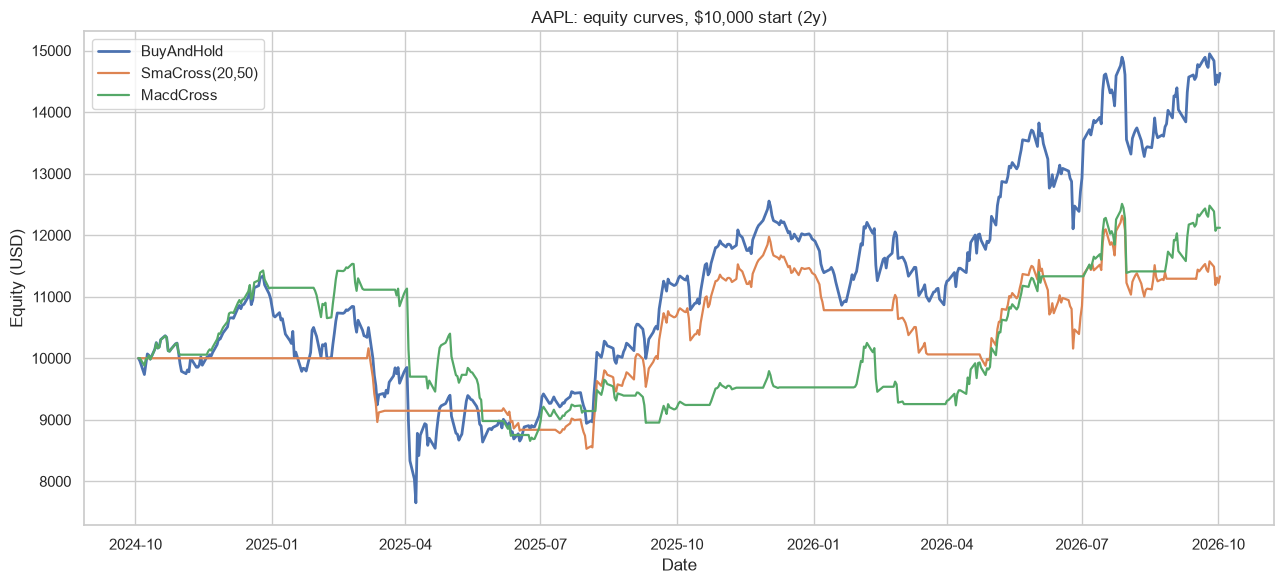

final equity — BuyAndHold: 14,630 | SmaCross(20,50): 11,331 | MacdCross: 12,120


In [7]:
# Three equity curves on one axis: the benchmark and two active rules.
macd = run_backtest(MacdCross(), history)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(bh.equity_curve.index, bh.equity_curve, linewidth=2.0, label="BuyAndHold")
ax.plot(sma_fast.equity_curve.index, sma_fast.equity_curve, linewidth=1.6, label="SmaCross(20,50)")
ax.plot(macd.equity_curve.index, macd.equity_curve, linewidth=1.6, label="MacdCross")
ax.set_title(f"{ticker}: equity curves, ${10_000:,} start ({period})")
ax.set_xlabel("Date")
ax.set_ylabel("Equity (USD)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"final equity — BuyAndHold: {bh.equity_curve.iloc[-1]:,.0f} | "
      f"SmaCross(20,50): {sma_fast.equity_curve.iloc[-1]:,.0f} | "
      f"MacdCross: {macd.equity_curve.iloc[-1]:,.0f}")

In this window buy-and-hold leads: the strategies are in cash part of the time, so they miss
upside. The MacdCross curve moves in visible steps — flat whenever it is out of the market, then
jumping when re-invested. That flat-vs-invested switching is the whole game, and it is also why
trade frequency matters once costs exist.

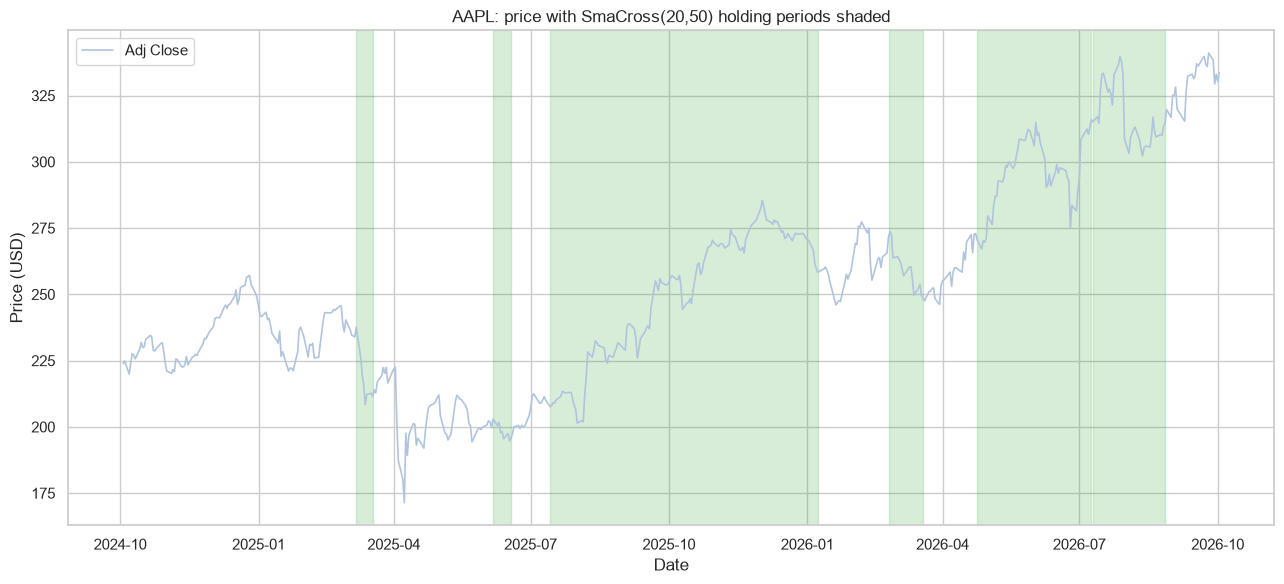

shaded spans = 6 closed trades (time in the market)


In [8]:
# Where was SmaCross(20,50) flat vs invested? Shade its holding periods on the price chart.
close = price_series(history)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(close.index, close, color="lightsteelblue", linewidth=1.2, label="Adj Close")

for row in sma_fast.trades.itertuples(index=False):
    ax.axvspan(row.entry_time, row.exit_time, color="tab:green", alpha=0.18)

ax.set_title(f"{ticker}: price with SmaCross(20,50) holding periods shaded")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print("shaded spans =", len(sma_fast.trades), "closed trades (time in the market)")

## Comparing many strategies at once

Rather than eyeballing one report at a time, collect each strategy's metrics into a single
DataFrame: rows = strategies, columns = the numbers we care about. This is the first table a
quant looks at — it shows at a glance who is worth a deeper look and who simply did nothing.

In [9]:
strategies = {
    "BuyAndHold": BuyAndHold(),
    "SmaCross(20,50)": SmaCross(fast=20, slow=50),
    "RsiReversion": RsiReversion(),
    "MacdCross": MacdCross(),
    "BollingerBreakout": BollingerBreakout(),
}

cols = [
    "total_return",
    "cagr",
    "annualized_volatility",
    "sharpe",
    "max_drawdown",
    "n_trades",
    "win_rate",
    "profit_factor",
]

comparison = pd.DataFrame(
    {name: {c: run_backtest(s, history).metrics[c] for c in cols} for name, s in strategies.items()}
).T.sort_values("total_return", ascending=False)

comparison.round(4)

,total_return,cagr,annualized_volatility,sharpe,max_drawdown,n_trades,win_rate,profit_factor
BuyAndHold,0.4630,0.2114,0.2801,0.8240,-0.3253,0.0,0.0000,0.0000
BollingerBreakout,0.2524,0.1201,0.1472,0.8440,-0.1323,5.0,0.4000,3.1225
MacdCross,0.2120,0.1018,0.1826,0.6230,-0.2494,19.0,0.6316,1.6730
RsiReversion,0.1502,0.0731,0.2211,0.4280,-0.2915,2.0,1.0000,inf
"SmaCross(20,50)",0.1331,0.0650,0.1732,0.4502,-0.1751,6.0,0.3333,1.6404


Read the table top to bottom. Whoever leads on `total_return` here leads **in this one window,
on this one ticker**. Buy-and-hold is a brutal benchmark: it is fully exposed to every rally, so
most timing rules underperform it in a rising market unless they dodge real drawdowns. If one of
the strategies did beat it, that is *not* evidence of skill — it is one sample. A single lucky
window produces impressive numbers from randomness all the time.

The honest version of this table would re-run every strategy on many tickers, many start dates,
and — critically — a slice of data the rules were **never tuned on** (an out-of-sample test).
That last part is where most bright backtests die.

## The overfitting warning

A strategy with many parameters is a strategy with many ways to memorise the past. If you try
5,000 combinations and keep the best, you have not discovered an edge — you have found the
combination that best fits noise. It will backtest brilliantly and trade badly, because the
noise it memorised is not there in the future.

More parameters = more rope. A rule with two knobs and an economic reason is worth more than a
rule with twenty knobs and a beautiful curve. Always ask: *does this rule have a reason to work,
or does it just fit?*

## What this engine honestly leaves out

- **No slippage** — real fills are worse than the quoted price, especially in size.
- **No latency or queue position** — your order is not the only one racing for that price.
- **No partial fills** — this engine always fills the whole order or none of it.
- **Flat commission** that defaults to `0.0` — pass `commission=` to `run_backtest` to see the drag.
- **Whole shares only** — no fractional positions.
- **No taxes or borrow costs** — ignored entirely.
- **The 2%-of-cash buffer** in all-in sizing: when a strategy goes all-in it spends only ~98% of
  cash, so an overnight gap-up in the next open does not push the fill above the cash available
  and get the order rejected. It is a small, explicit concession to reality.

Every one of these flatters the backtest. Treat the numbers as an *upper bound* and the shape of
the curve as the thing you are actually judging.

## Recap
1. A backtest is a mechanical replay, and its integrity rests on one rule: a signal from bar
   *i*'s close fills at bar *i+1*'s open. No lookahead, ever.
2. Metrics are a profile, not a verdict — read return **with** drawdown, Sharpe, and trade count;
   each number alone hides something important.
3. `n_trades` counts *closed* round trips, so zero trades can still hide an open position: read
   `.orders` and the position alongside it. A long-window rule on a short slice is a mismatch of
   parameters and window, not proof that the rule is broken.
4. A great backtest is a hypothesis, not proof. Beat buy-and-hold on one window and you have
   learned almost nothing until you test out of sample on other tickers and dates.

**Try this:** swap `ticker = "MSFT"` (or `"SPY"`) and rerun the whole comparison — do the same
strategies still lead? Then re-run the comparison with `run_backtest(s, history, commission=5.0)`
and watch how the high-trade-count strategies (MacdCross, BollingerBreakout) lose more of their
return to fees than buy-and-hold does.